In [1]:
import tensorflow as tf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten, Conv2D,Dropout,Input,GlobalMaxPooling2D
from tensorflow.keras.models import Model

In [3]:
# Load the data
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print(x_train.shape,y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3) (50000,)


In [4]:
#number of classes
K = len(set(y_train))
print(K)

10


In [ ]:
# Build the model using the functional API
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)
model = Model(i, x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 15, 15, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       1,180,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │          10,250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,284,170 (4.90 MB)

 Trainable params: 1,284,170 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and fit
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.3764 - loss: 1.6990 - val_accuracy: 0.5598 - val_loss: 1.2323
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5723 - loss: 1.1937 - val_accuracy: 0.6200 - val_loss: 1.0681
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6375 - loss: 1.0205 - val_accuracy: 0.6424 - val_loss: 1.0207
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6881 - loss: 0.8819 - val_accuracy: 0.6612 - val_loss: 0.9681
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7229 - loss: 0.7805 - val_accuracy: 0.6935 - val_loss: 0.8885
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7609 - loss: 0.6703 - val_accuracy: 0.6908 - val_loss: 0.8977
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7883 - loss: 0.5963 - val_accuracy: 0.7003 - val_loss: 0.8777
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8164 - loss: 0.52

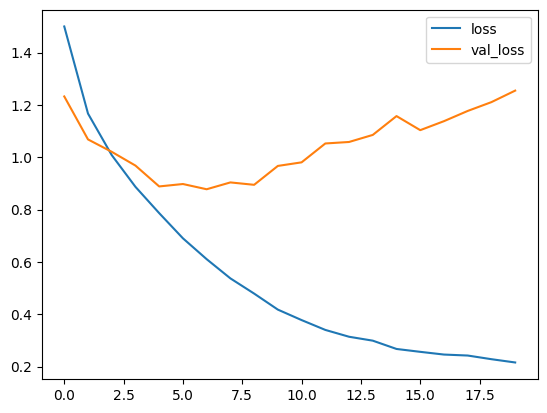

In [ ]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

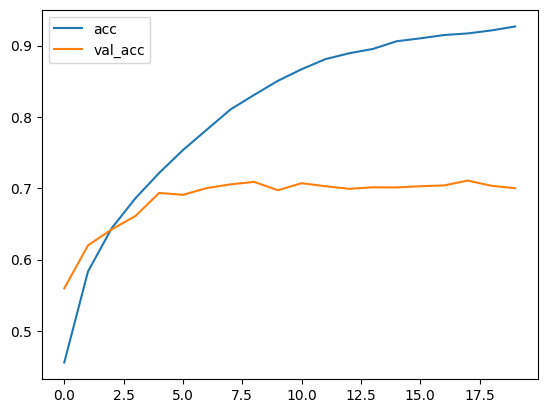

In [ ]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion matrix, without normalization
[[758  28  39  23  19  11   9  15  56  42]
 [ 11 842   5   7   5   8   9   5  20  88]
 [ 75   6 564  85  84  90  44  34  11   7]
 [ 17  12  53 534  49 232  43  39   7  14]
 [ 24   2  69  92 618  63  31  85  12   4]
 [ 14   7  29 189  41 650   7  50   6   7]
 [  6   9  34  95  49  52 732  11   2  10]
 [ 12   3  29  41  54  94   6 747   6   8]
 [ 70  41  15  22  12  11   9   7 785  28]
 [ 28 101   9  20   2  23   6  18  22 771]]


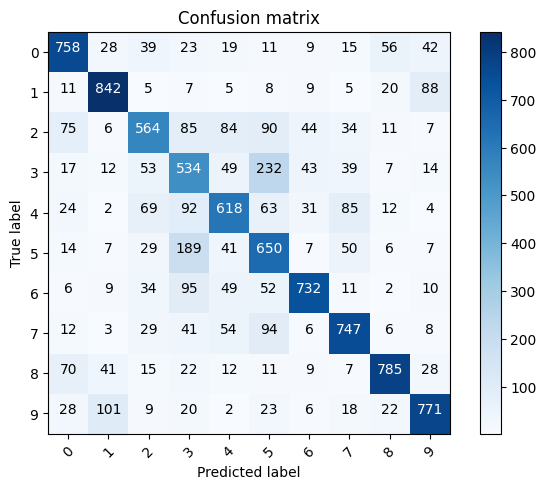

In [ ]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

def plot_confusion_matrix(cm,classes,
                          normalize=False,
                          Title="Confusion matrix",
                          cmap=plt.cm.Blues):


  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(Title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color='white' if cm[i, j] > thresh else 'black')

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [ ]:
# Label mapping
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

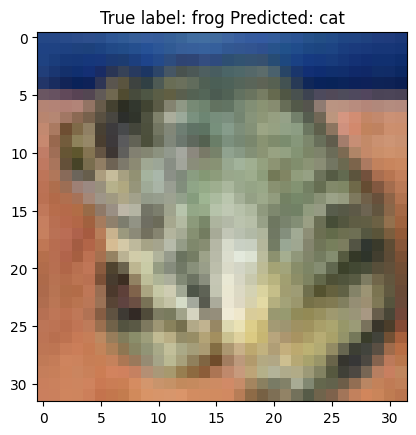

In [ ]:
# Show some misclassified examples
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(32,32,3), cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));

------

In [ ]:
# Build the model using the functional API
i = Input(shape=x_train[0].shape)
x = Conv2D(2, (3, 3), strides=1, activation='relu', padding='same')(i) # changed stride to 1 and padding to 'same'
x = Conv2D(4, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'
x = Conv2D(8, (3, 3), strides=2, activation='relu', padding='same')(x) # changed padding to 'same'
x = Conv2D(16, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'
x = Conv2D(32, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'
x = Conv2D(64, (3, 3), strides=2, activation='relu', padding='same')(x) # changed padding to 'same'
x = Conv2D(128, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'
x = Conv2D(256, (3, 3), strides=2, activation='relu', padding='same')(x) # changed padding to 'same'
x = Conv2D(512, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'
x = Conv2D(1024, (3, 3), strides=1, activation='relu', padding='same')(x) # changed stride to 1 and padding to 'same'


x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(2048, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)
model = Model(i, x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 32, 32, 2)           │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 4)           │              76 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 8)           │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 16, 16, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 8, 8, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 4, 4, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 4, 4, 1024)          │       4,719,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2048)                │      33,556,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │          20,490 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,870,502 (152.09 MB)

 Trainable params: 39,870,502 (152.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and fit
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.0961 - loss: 2.3041 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.1007 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.1004 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.0963 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.0987 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.0993 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.0986 -

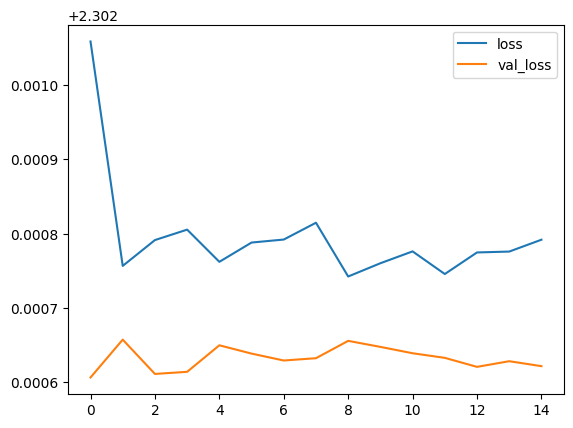

In [ ]:
# Plot loss per iteration
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

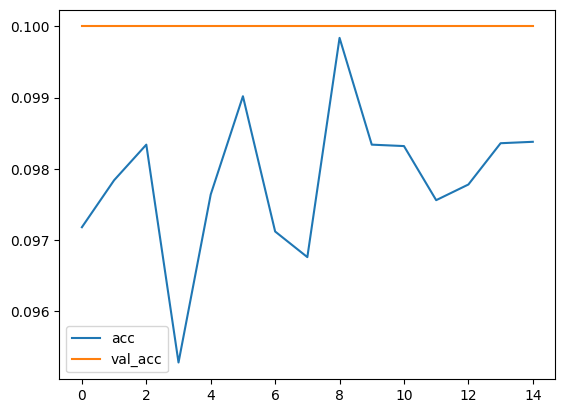

In [ ]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Confusion matrix, without normalization
[[   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]
 [   0 1000    0    0    0    0    0    0    0    0]]


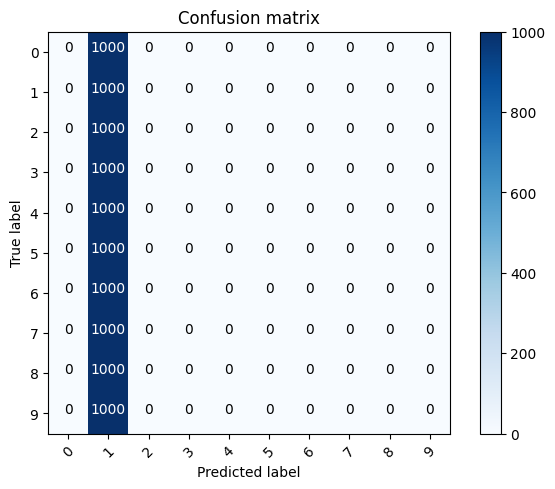

In [ ]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

def plot_confusion_matrix(cm,classes,
                          normalize=False,
                          Title="Confusion matrix",
                          cmap=plt.cm.Blues):


  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(Title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color='white' if cm[i, j] > thresh else 'black')

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

# ChatGPT


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Model

# Giriş katmanı: x_train örneklerinin şekline göre düzenleyin.
inputs = Input(shape=x_train[0].shape)

# 1. Konvolüsyon Bloku: 32 filtre
x = Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)  # Boyutları yarıya indirir
x = Dropout(0.25)(x)

# 2. Konvolüsyon Bloku: 64 filtre
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# 3. Konvolüsyon Bloku: 128 filtre
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# Yoğun katmanlar
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(K, activation='softmax')(x)

# Modelin tanımlanması
model_gpt = Model(inputs, outputs)
model_gpt.summary()

# Modelin derlenmesi
model_gpt.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Modelin eğitilmesi
r = model_gpt.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - accuracy: 0.3781 - loss: 1.8484 - val_accuracy: 0.4870 - val_loss: 1.5221
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - accuracy: 0.6223 - loss: 1.0640 - val_accuracy: 0.6487 - val_loss: 1.0082
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6924 - loss: 0.8773 - val_accuracy: 0.7318 - val_loss: 0.7766
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7306 - loss: 0.7744 - val_accuracy: 0.7478 - val_loss: 0.7334
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.7580 - loss: 0.6985 - val_accuracy: 0.7888 - val_loss: 0.6081
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7776 - loss: 0.6453 - val_accuracy: 0.7820 - val_loss: 0.6297
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7999 - loss: 0.5876 - val_accuracy: 0.8083 - val_loss: 0.5531
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8160 - los

# DeepSeek

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_advanced_cnn(input_shape, num_classes):
    # Input layer
    inputs = Input(shape=input_shape)

    # Convolutional Blocks with increasing complexity
    x = Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Advanced top layers
    x = GlobalAveragePooling2D()(x)  # Flatten yerine daha iyi genelleme
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model_deep_seek = Model(inputs, outputs)
    return model_deep_seek

# Modeli oluştur
model_deep_seek = build_advanced_cnn(x_train[0].shape, K)
model_deep_seek.summary()

# Optimizer ve learning rate ayarı
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001, weight_decay=1e-4)

# Early Stopping callback
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Model derleme
model_deep_seek.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# Model eğitimi
history = model_deep_seek.fit(datagen.flow(x_train, y_train, batch_size=128),
                    epochs=20,  # Daha uzun eğitim
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop])

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_15 (Activation)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 490,794 (1.87 MB)

 Trainable params: 488,874 (1.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 62s 120ms/step - accuracy: 0.2663 - loss: 5.4183 - val_accuracy: 0.4118 - val_loss: 2.2612
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.4759 - loss: 1.8815 - val_accuracy: 0.3967 - val_loss: 2.0165
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.5490 - loss: 1.4025 - val_accuracy: 0.5166 - val_loss: 1.6572
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.5849 - loss: 1.2703 - val_accuracy: 0.5688 - val_loss: 1.3874
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.6080 - loss: 1.1997 - val_accuracy: 0.6057 - val_loss: 1.2362
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.6380 - loss: 1.1317 - val_accuracy: 0.6536 - val_loss: 1.0528
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.6539 - loss: 1.0833 - val_accuracy: 0.6782 - val_loss: 1.0650
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.6731 - loss: 1.0371 - val_accura

# Cloude AI

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 16, 16, 64)     │          9,472 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn1 (BatchNormalization)  │ (None, 16, 16, 64)     │            256 │ conv1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu1 (Activation)        │ (None, 16, 16, 64)     │              0 │ bn1[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 8, 8, 64)       │              0 │ relu1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_conv1 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_bn1                │ (None, 8, 8, 64)       │            256 │ res1_1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_relu1 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_1_bn1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_conv2 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_1_relu1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_bn2                │ (None, 8, 8, 64)       │            256 │ res1_1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_add (Add)          │ (None, 8, 8, 64)       │              0 │ res1_1_bn2[0][0],      │
│                           │                        │                │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_relu2 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_1_add[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_conv1 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_1_relu2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_bn1                │ (None, 8, 8, 64)       │            256 │ res1_2_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_relu1 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_2_bn1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_conv2 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_2_relu1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_bn2                │ (None, 8, 8, 64)       │            256 │ res1_2_conv2[0][0]     │
│ (BatchNormalization) 

 Total params: 17,632,394 (67.26 MB)

 Trainable params: 17,619,722 (67.21 MB)

 Non-trainable params: 12,672 (49.50 KB)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 72ms/step - accuracy: 0.3452 - loss: 2.0260 - val_accuracy: 0.3487 - val_loss: 1.7926 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5711 - loss: 1.2273 - val_accuracy: 0.3598 - val_loss: 2.1485 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6648 - loss: 0.9842 - val_accuracy: 0.5692 - val_loss: 1.2805 - learning_rate: 0.0010
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.7120 - loss: 0.8429 - val_accuracy: 0.5378 - val_loss: 1.6162 - learning_rate: 0.0010
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7504 - loss: 0.7410 - val_accuracy: 0.6718 - val_loss: 0.9826 - learning_rate: 0.0010
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.7779 - loss: 0.6509 - val_accuracy: 0.6742 - val_loss: 1.0209 - learning_rate: 0.0010
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8066 - l

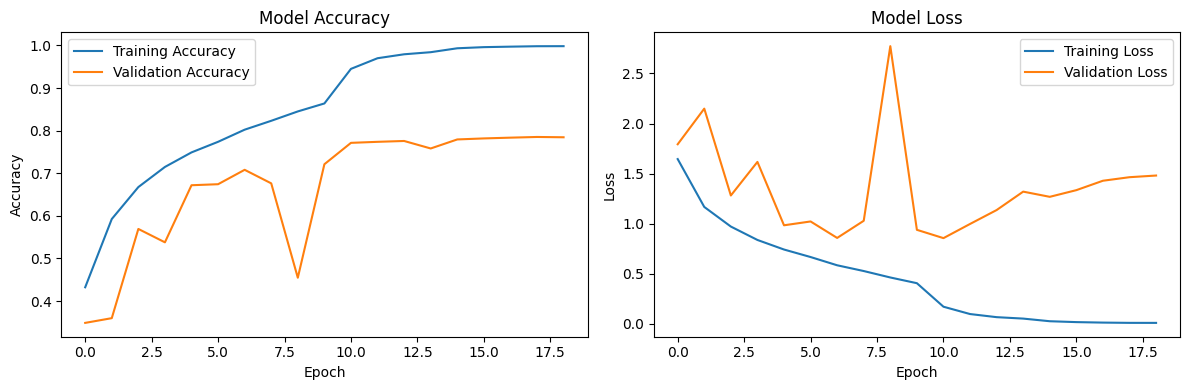

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7737 - loss: 0.8321
Test accuracy: 0.7713


In [ ]:
# Import necessary libraries
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Dense, Flatten, GlobalAveragePooling2D, Activation, add

# Build the model using Residual Blocks for better gradient flow
def residual_block(x, filters, kernel_size=3, stride=1, use_bias=True, name=None):
    shortcut = x

    x = Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=use_bias, name=f'{name}_conv1')(x)
    x = BatchNormalization(name=f'{name}_bn1')(x)
    x = Activation('relu', name=f'{name}_relu1')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=use_bias, name=f'{name}_conv2')(x)
    x = BatchNormalization(name=f'{name}_bn2')(x)

    # If shapes don't match, adjust shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=use_bias, name=f'{name}_shortcut')(shortcut)
        shortcut = BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    x = add([x, shortcut], name=f'{name}_add')
    x = Activation('relu', name=f'{name}_relu2')(x)

    return x

# Input layer
i = Input(shape=x_train[0].shape)

# Initial convolution
x = Conv2D(64, (7, 7), strides=2, padding='same', use_bias=True, name='conv1')(i)
x = BatchNormalization(name='bn1')(x)
x = Activation('relu', name='relu1')(x)
x = MaxPooling2D((3, 3), strides=2, padding='same', name='pool1')(x)

# Residual blocks
x = residual_block(x, 64, name='res1_1')
x = residual_block(x, 64, name='res1_2')

x = residual_block(x, 128, stride=2, name='res2_1')
x = residual_block(x, 128, name='res2_2')

x = residual_block(x, 256, stride=2, name='res3_1')
x = residual_block(x, 256, name='res3_2')
x = residual_block(x, 256, name='res3_3')

x = residual_block(x, 512, stride=2, name='res4_1')
x = residual_block(x, 512, name='res4_2')
x = residual_block(x, 512, name='res4_3')

# Global pooling and classification
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dropout(0.5)(x)  # Higher dropout for better regularization
x = Dense(1024, activation='relu', name='fc1')(x)
x = Dropout(0.3)(x)
x = Dense(K, activation='softmax', name='fc2')(x)

# Create model
model_cloude = Model(i, x)
model_cloude.summary()

# Compile with better settings
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Create learning rate scheduler and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

# Compile model with a lower learning rate
opt = Adam(learning_rate=0.001)
model_cloude.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit with callbacks
r = model_cloude.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,  # More epochs with early stopping
    batch_size=128,  # Consider adjusting batch size based on your data
    callbacks=[reduce_lr, early_stopping]
)

# Visualize the training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# If you have a test set, evaluate the model
test_loss, test_acc = model_cloude.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

# DAHA DERİN MODEL HALLERİ


## ChatGPT

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Model

# Giriş katmanı: x_train örneklerinin şeklini kullanın.
inputs = Input(shape=x_train[0].shape)

# --- Block 1: 2 Konvolüsyon Katmanı (64 filtre) ---
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# --- Block 2: 2 Konvolüsyon Katmanı (128 filtre) ---
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# --- Block 3: 3 Konvolüsyon Katmanı (256 filtre) ---
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# --- Block 4: 3 Konvolüsyon Katmanı (512 filtre) ---
x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

# --- Fully Connected Katmanlar ---
x = Flatten()(x)
x = Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(K, activation='softmax')(x)

# Modelin oluşturulması
model_gpt2 = Model(inputs, outputs)
model_gpt2.summary()

# Modelin derlenmesi ve eğitilmesi
model_gpt2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

r = model_gpt2.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_18 (Activation)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_19 (Activation)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_39 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_20 (Activation)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_21 (Activation)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 32,861,002 (125.35 MB)

 Trainable params: 32,855,626 (125.33 MB)

 Non-trainable params: 5,376 (21.00 KB)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 46ms/step - accuracy: 0.1674 - loss: 2.5130 - val_accuracy: 0.2523 - val_loss: 1.8920
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.2983 - loss: 1.7586 - val_accuracy: 0.3354 - val_loss: 1.6876
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.4097 - loss: 1.5917 - val_accuracy: 0.4502 - val_loss: 1.5514
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.5358 - loss: 1.3389 - val_accuracy: 0.5740 - val_loss: 1.2213
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.6061 - loss: 1.1403 - val_accuracy: 0.6804 - val_loss: 0.9341
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.6740 - loss: 0.9747 - val_accuracy: 0.7026 - val_loss: 0.8940
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.7105 - loss: 0.8581 - val_accuracy: 0.7495 - val_loss: 0.7310
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7559 -

## DeepSeek

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True):
    if conv_shortcut:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', kernel_initializer='he_normal')(x)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = x

    x = Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x

def build_deep_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Initial Convolution
    x = Conv2D(64, 7, strides=2, padding='same', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same')(x)

    # Residual Blocks
    x = residual_block(x, 64, conv_shortcut=False)
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    x = residual_block(x, 256)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)
    x = residual_block(x, 512)

    # Top Layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# Modeli oluştur
model_deep_seek_2 = build_deep_cnn(x_train[0].shape, K)
model_deep_seek_2.summary()

# Optimizer ve Callback'ler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, weight_decay=1e-4)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

# Model Derleme
model_deep_seek_2.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Gelişmiş Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Model Eğitimi
history = model_deep_seek_2.fit(
    datagen.flow(x_train, y_train, batch_size=256),
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 16, 16, 64)     │          9,472 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_31    │ (None, 16, 16, 64)     │            256 │ conv2d_47[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_28             │ (None, 16, 16, 64)     │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_13          │ (None, 8, 8, 64)       │              0 │ activation_28[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 8, 8, 64)       │         36,928 │ max_pooling2d_13[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_32    │ (None, 8, 8, 64)       │            256 │ conv2d_48[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_29             │ (None, 8, 8, 64)       │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 8, 8, 64)       │         36,928 │ activation_29[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_33    │ (None, 8, 8, 64)       │            256 │ conv2d_49[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 8, 8, 64)       │              0 │ max_pooling2d_13[0][0… │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_30             │ (None, 8, 8, 64)       │              0 │ add[0][0]              │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_51 (Conv2D)        │ (None, 8, 8, 64)       │         36,928 │ activation_30[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_35    │ (None, 8, 8, 64)       │            256 │ conv2d_51[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_31        

 Total params: 19,228,554 (73.35 MB)

 Trainable params: 19,211,274 (73.29 MB)

 Non-trainable params: 17,280 (67.50 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.2212 - loss: 2.2999 - val_accuracy: 0.3420 - val_loss: 1.8872 - learning_rate: 0.0010
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accuracy: 0.3848 - loss: 1.8057 - val_accuracy: 0.4494 - val_loss: 1.7090 - learning_rate: 0.0010
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 172ms/step - accuracy: 0.4522 - loss: 1.6296 - val_accuracy: 0.3402 - val_loss: 2.4086 - learning_rate: 0.0010
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - accuracy: 0.4893 - loss: 1.5339 - val_accuracy: 0.4531 - val_loss: 1.9201 - learning_rate: 0.0010
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.5240 - loss: 1.4287 - val_accuracy: 0.5032 - val_loss: 1.4822 - learning_rate: 0.0010
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 183ms/step - accuracy: 0.5445 - loss: 1.3720 - val_accuracy: 0.5445 - val_loss: 1.5266 - learning_rate: 0.0010
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 185ms/step - accuracy: 0.5

## Cloude

In [ ]:
# Import necessary libraries
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Dense, Flatten
from tensorflow.keras.layers import GlobalAveragePooling2D, Activation, add, concatenate, AveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Inception module function
def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, filters_5x5_reduce,
                      filters_5x5, filters_pool_proj, name=None):
    conv_1x1 = Conv2D(filters_1x1, (1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_1x1')(x)

    conv_3x3_reduce = Conv2D(filters_3x3_reduce, (1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_3x3_reduce')(x)
    conv_3x3 = Conv2D(filters_3x3, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_3x3')(conv_3x3_reduce)

    conv_5x5_reduce = Conv2D(filters_5x5_reduce, (1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_5x5_reduce')(x)
    conv_5x5 = Conv2D(filters_5x5, (5, 5), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_5x5')(conv_5x5_reduce)

    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same', name=f'{name}_pool')(x)
    pool_proj = Conv2D(filters_pool_proj, (1, 1), padding='same', activation='relu', kernel_regularizer=l2(0.0001), name=f'{name}_pool_proj')(pool_proj)

    output = concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=3, name=f'{name}_concat')

    return output

# Residual block function for deeper networks
def residual_block(x, filters, kernel_size=3, stride=1, use_bias=True, name=None):
    shortcut = x

    x = Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=use_bias, kernel_regularizer=l2(0.0001), name=f'{name}_conv1')(x)
    x = BatchNormalization(name=f'{name}_bn1')(x)
    x = Activation('relu', name=f'{name}_relu1')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=use_bias, kernel_regularizer=l2(0.0001), name=f'{name}_conv2')(x)
    x = BatchNormalization(name=f'{name}_bn2')(x)

    # Adjust shortcut if dimensions don't match
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=use_bias, kernel_regularizer=l2(0.0001), name=f'{name}_shortcut')(shortcut)
        shortcut = BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)

    x = add([x, shortcut], name=f'{name}_add')
    x = Activation('relu', name=f'{name}_relu2')(x)

    return x

# Dense block - from DenseNet architecture
def dense_block(x, blocks, growth_rate, name='dense_block'):
    for i in range(blocks):
        x = dense_layer(x, growth_rate, name=f'{name}_layer_{i}')
    return x

def dense_layer(x, growth_rate, name):
    x1 = BatchNormalization(name=f'{name}_bn1')(x)
    x1 = Activation('relu', name=f'{name}_relu1')(x1)
    x1 = Conv2D(4 * growth_rate, (1, 1), padding='same', use_bias=False, kernel_regularizer=l2(0.0001), name=f'{name}_conv1')(x1)

    x1 = BatchNormalization(name=f'{name}_bn2')(x1)
    x1 = Activation('relu', name=f'{name}_relu2')(x1)
    x1 = Conv2D(growth_rate, (3, 3), padding='same', use_bias=False, kernel_regularizer=l2(0.0001), name=f'{name}_conv2')(x1)

    x = concatenate([x, x1], axis=3, name=f'{name}_concat')
    return x

# Transition layer - modified
def transition_layer(x, compression=0.5, name='transition'):
    channels = int(x.shape[-1] * compression)
    x = BatchNormalization(name=f'{name}_bn')(x)
    x = Activation('relu', name=f'{name}_relu')(x)
    x = Conv2D(channels, (1, 1), padding='same', use_bias=False, kernel_regularizer=l2(0.0001), name=f'{name}_conv')(x)

    # Check dimensions - skip pooling if dimensions are 1x1
    height, width = x.shape[1:3]
    if height > 1 and width > 1:
        x = AveragePooling2D((2, 2), strides=2, name=f'{name}_pool')(x)

    return x

# Model structure
def create_deep_hybrid_model(input_shape, num_classes):
    # Input layer
    inputs = Input(shape=input_shape)

    # Initial convolution layers
    x = Conv2D(64, (7, 7), strides=2, padding='same', use_bias=True, kernel_regularizer=l2(0.0001), name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = Activation('relu', name='relu1')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same', name='pool1')(x)

    # Residual blocks
    x = residual_block(x, 64, name='res1_1')
    x = residual_block(x, 64, name='res1_2')
    x = residual_block(x, 64, name='res1_3')

    # Check current dimensions
    current_shape = x.shape
    print(f"Shape after first residual blocks: {current_shape}")

    # Adjust stride conditionally
    stride_value = 1 if current_shape[1] <= 8 else 2  # If height <= 8, use stride 1

    x = residual_block(x, 128, stride=stride_value, name='res2_1')
    x = residual_block(x, 128, name='res2_2')
    x = residual_block(x, 128, name='res2_3')
    x = residual_block(x, 128, name='res2_4')

    # Check dimensions again
    current_shape = x.shape
    print(f"Shape after second residual blocks: {current_shape}")

    # Inception modules - padding 'same' preserves dimensions
    x = inception_module(x, filters_1x1=64, filters_3x3_reduce=96, filters_3x3=128,
                         filters_5x5_reduce=16, filters_5x5=32, filters_pool_proj=32, name='inception1')

    x = inception_module(x, filters_1x1=128, filters_3x3_reduce=128, filters_3x3=192,
                         filters_5x5_reduce=32, filters_5x5=96, filters_pool_proj=64, name='inception2')

    current_shape = x.shape
    print(f"Shape after inception modules: {current_shape}")

    # Adjust stride based on dimensions
    stride_value = 1 if current_shape[1] <= 4 else 2

    # Continue with residual blocks - conditional stride
    x = residual_block(x, 256, stride=stride_value, name='res3_1')
    x = residual_block(x, 256, name='res3_2')
    x = residual_block(x, 256, name='res3_3')
    x = residual_block(x, 256, name='res3_4')

    current_shape = x.shape
    print(f"Shape before dense blocks: {current_shape}")

    # Dense blocks - using only one dense block due to small dimensions
    x = dense_block(x, blocks=4, growth_rate=32, name='denseblock1')
    x = transition_layer(x, compression=0.5, name='transition1')

    current_shape = x.shape
    print(f"Shape after first dense block: {current_shape}")

    # Check if dimensions allow for a second dense block
    if current_shape[1] > 1 and current_shape[2] > 1:
        x = dense_block(x, blocks=4, growth_rate=32, name='denseblock2')
        x = transition_layer(x, compression=0.5, name='transition2')

    current_shape = x.shape
    print(f"Shape after second dense block (if used): {current_shape}")

    # Final residual blocks - adjust stride based on dimensions
    stride_value = 1  # No more downsampling possible

    x = residual_block(x, 512, stride=stride_value, name='res4_1')
    x = residual_block(x, 512, name='res4_2')
    x = residual_block(x, 512, name='res4_3')

    # Global pooling and classification
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dropout(0.5)(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.0001), name='fc1')(x)
    x = Dropout(0.3)(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.0001), name='fc2')(x)
    x = Dropout(0.2)(x)
    x = Dense(num_classes, activation='softmax', name='predictions')(x)

    # Create model
    model = Model(inputs=inputs, outputs=x)
    return model

# Create model
model_cloude_2 = create_deep_hybrid_model(x_train[0].shape, K)
model_cloude_2.summary()

# Advanced settings for model compilation and training
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import math

# Learning rate scheduler
def step_decay(epoch):
    initial_lr = 0.001
    drop = 0.5
    epochs_drop = 10.0
    lr = initial_lr * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return max(lr, 1e-6)  # Minimum learning rate

# Create callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
# Fix: Change save format to .keras instead of .h5
checkpoint = ModelCheckpoint('best_deep_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
lr_scheduler = LearningRateScheduler(step_decay, verbose=1)

# Compile model
opt = Adam(learning_rate=0.001)
model_cloude_2.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Data augmentation if needed
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fix: Use repeat() to ensure we don't run out of data
# Create a proper generator that doesn't run out of data
train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=32,
    shuffle=True
)

# Fix: Update the model.fit with steps_per_epoch and ensure dataset doesn't run out
# Model training
r = model_cloude_2.fit(
    train_generator,
    validation_data=(x_test, y_test),
    epochs=100,  # More epochs with early stopping
    steps_per_epoch=len(x_train) // 32,  # Ensure correct steps_per_epoch
    callbacks=[reduce_lr, early_stopping, checkpoint, lr_scheduler]
)

# Visualize training history
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show learning rate changes
lr_hist = []
for i in range(len(r.history['loss'])):
    lr_hist.append(step_decay(i))

plt.subplot(1, 3, 3)
plt.plot(lr_hist)
plt.title('Learning Rate Over Time')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')

plt.tight_layout()
plt.show()

# Test evaluation
# Fix: Load weights from .keras file instead of .h5
model_cloude_2.load_weights('best_deep_model.keras')  # Load the best model
test_loss, test_acc = model_cloude_2.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

Shape after first residual blocks: (None, 8, 8, 64)
Shape after second residual blocks: (None, 8, 8, 128)
Shape after inception modules: (None, 8, 8, 480)
Shape before dense blocks: (None, 4, 4, 256)
Shape after first dense block: (None, 2, 2, 192)
Shape after second dense block (if used): (None, 1, 1, 160)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 32, 32, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 16, 16, 64)     │          9,472 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn1 (BatchNormalization)  │ (None, 16, 16, 64)     │            256 │ conv1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu1 (Activation)        │ (None, 16, 16, 64)     │              0 │ bn1[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 8, 8, 64)       │              0 │ relu1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_conv1 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_bn1                │ (None, 8, 8, 64)       │            256 │ res1_1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_relu1 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_1_bn1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_conv2 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_1_relu1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_bn2                │ (None, 8, 8, 64)       │            256 │ res1_1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_add (Add)          │ (None, 8, 8, 64)       │              0 │ res1_1_bn2[0][0],      │
│                           │                        │                │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_1_relu2 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_1_add[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_conv1 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_1_relu2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_bn1                │ (None, 8, 8, 64)       │            256 │ res1_2_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_relu1 (Activation) │ (None, 8, 8, 64)       │              0 │ res1_2_bn1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_conv2 (Conv2D)     │ (None, 8, 8, 64)       │         36,928 │ res1_2_relu1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res1_2_bn2                │ (None, 8, 8, 64)       │            256 │ res1_2_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 21,663,738 (82.64 MB)

 Trainable params: 21,640,954 (82.55 MB)

...


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2181 - loss: 3.0810
Epoch 1: val_accuracy improved from -inf to 0.32300, saving model to best_deep_model.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 229s 92ms/step - accuracy: 0.2181 - loss: 3.0808 - val_accuracy: 0.3230 - val_loss: 2.7669 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/100
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 2:05 80ms/step - accuracy: 0.3750 - loss: 2.3797

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.32300
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3750 - loss: 2.3797 - val_accuracy: 0.3224 - val_loss: 2.7298 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/100
1561/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3492 - loss: 2.3495
Epoch 3: val_accuracy improved from 0.32300 to 0.36910, saving model to best_deep_model.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.3492 - loss: 2.3494 - val_accuracy: 0.3691 - val_loss: 2.1789 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/100
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:43 66ms/step - accuracy: 0.4375 - loss: 1.8575
Epoch 4: val_accuracy did not improve from 0.36910
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4375 - loss: 1.8575 - val_accuracy: 0.3674 - val_loss: 2.1871 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001